# A Simulation of the BB84 Quantum Key Distribution (QKD) Protocol


## 1. Setup & Utilities

- Import necessary packages

In [699]:
import qiskit
import math
import random
import numpy as np
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error

- Save credentials locally. This is one-time setup, does not need to re-run every times we build the notebook.

In [701]:
# from qiskit_ibm_runtime import QiskitRuntimeService
# Stores credentials locally
# one-time setup
# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",
#     token="<token>",
#     overwrite=True,
#     set_as_default=True
# )


Connect to IBM Quantum hardware and choose the hardware

In [703]:
# Connect to IBM Quantum hardware
service = QiskitRuntimeService()

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=127
)

print("Backend:", backend.name)

management.get:WARNING:2026-04-08 17:17:30,305: Loading default saved account
qiskit_runtime_service.__init__:WARNING:2026-04-08 17:17:32,497: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-08 17:17:32,803: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-08 17:17:34,066: Using instance: open-instance, plan: open


Backend: ibm_marrakesh


- Helpers for experiments

In [705]:
def get_rn_generator(seed=None):
    """
    This helper create a random number generator

    Params:
        seed: Random seed for reproducibility. If None, results vary each run.

    Returns:
         A random number generator
    """
    return np.random.default_rng(seed)

def sample_bits(bit_num, rng):
    """Sample an array of random 0|1 bits."""
    return rng.integers(0, 2, size=bit_num)

def encode_bb84_states(qc, bits, bases):
    """
    Encode BB84 states onto the qubits in-place.

    Convention:
    bit=0, basis=0 -> |0>
    bit=1, basis=0 -> |1>
    bit=0, basis=1 -> |+>
    bit=1, basis=1 -> |->
    """
    bit_num = len(bits)

    for n in range(bit_num):
        if bits[n] == 0:
            if bases[n] == 1:
                qc.h(n)
        if bits[n] == 1:
            if bases[n] == 0:
                qc.x(n)
            if bases[n] == 1:
                qc.x(n)
                qc.h(n)

def measure_bb84(qc, bases):
    """
    Measure qubits in BB84 bases in-place.

    basis=0 -> Z measurement
    basis=1 -> X measurement via H then Z measurement
    """
    bit_num = len(bases)

    for n in range(bit_num):
        if bases[n] == 1:
            qc.h(n)
        qc.measure(n, n)

def run_statevector_sampler(qc, shots=1):
    """
    Run a circuit locally with StatevectorSampler.
    """
    sampler = StatevectorSampler()
    return sampler.run([qc], shots=shots).result()


def extract_counts(result):
    """
    Extract both string and integer counts from result.
    """
    counts = result[0].data.c.get_counts()
    countsint = result[0].data.c.get_int_counts()
    return counts, countsint


def counts_to_bbits(counts, bit_num):
    """
    Convert the first measured bitstring in counts to Bob's bit array.

    Assumes shots=1 or that the first key is the one you want to inspect.
    Reverses bit order to match qubit indexing.
    """
    keys = counts.keys()
    key = list(keys)[0]
    bmeas = list(key)

    bmeas_ints = []
    for n in range(bit_num):
        bmeas_ints.append(int(bmeas[n]))

    bbits = bmeas_ints[::-1]
    return bbits


def sift_key(sender_bits, sender_bases, receiver_bases, receiver_bits):
    """
    Keep only positions where sender and receiver bases match.
    """
    sender_sifted = []
    receiver_sifted = []

    for n in range(len(sender_bits)):
        if sender_bases[n] == receiver_bases[n]:
            sender_sifted.append(int(sender_bits[n]))
            receiver_sifted.append(int(receiver_bits[n]))

    return sender_sifted, receiver_sifted


def key_statistics(sender_sifted, receiver_sifted):
    """
    Compute match count, fidelity, and loss for sifted keys.
    """
    if len(sender_sifted) == 0:
        return {
            "match_count": 0,
            "sifted_length": 0,
            "fidelity": None,
            "loss": None,
        }

    match_count = 0
    for n in range(len(sender_sifted)):
        if sender_sifted[n] == receiver_sifted[n]:
            match_count += 1

    fidelity = match_count / len(sender_sifted)
    loss = 1 - fidelity

    return {
        "match_count": match_count,
        "sifted_length": len(sender_sifted),
        "fidelity": fidelity,
        "loss": loss,
    }


def print_protocol_summary(abits, abase, bbase, bbits, agoodbits, bgoodbits, stats, ebits=None, ebase=None):
    """
    Print a compact summary for one BB84-like run.
    """
    print("Alice's bits are ", list(abits))
    print("Alice's bases are ", list(abase))
    if ebase is not None and ebits is not None:
        print("Eve base:   ", ebase)
        print("Eve bits:   ", ebits)
    print("Bob's bases are   ", list(bbase))
    print("Bob's measured bits:", bbits)
    print("Alice sifted key:", agoodbits)
    print("Bob sifted key:  ", bgoodbits)

    if stats["sifted_length"] > 0:
        print("match_count =", stats["match_count"])
        print("fidelity    =", stats["fidelity"])
        print("loss        =", stats["loss"])
    else:
        print("No sifted bits were produced.")
    


## 2. Experiment 1: Ideal BB84 QKD Simulate - No Noise, No Eve
This experiment simulate how Alice sends qubits and Bob measures them using random bases to generate a shared secret key.
- Alice encodes random bits into qubits using random bases (Z or X)
- Bob measures using random bases
- Later, they compare bases and keep only matching ones

BB84 with a noise-free simulator

Try  0


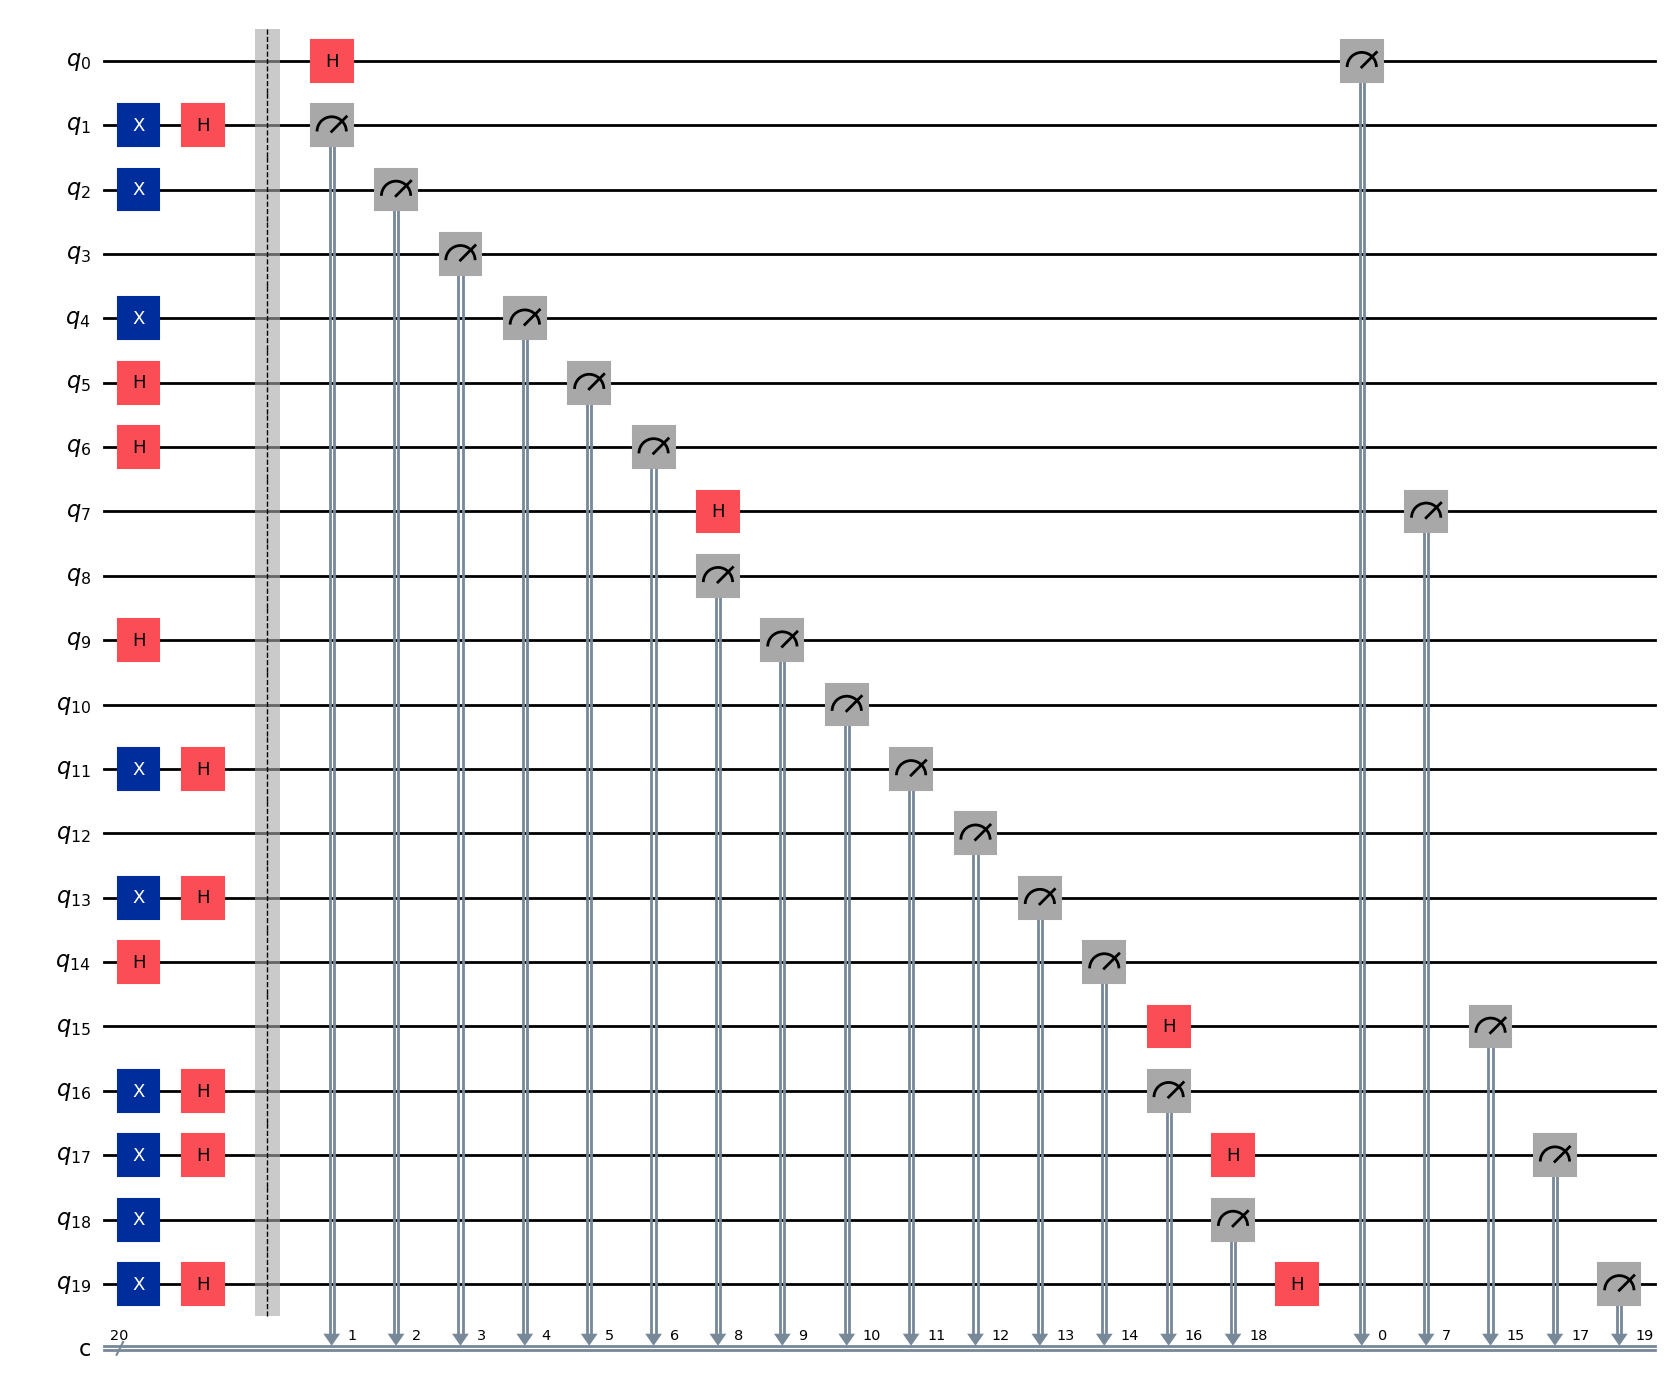

Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1]
Bob's bases are    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1]
Bob's measured bits: [0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 0, 1, 0, 0, 0, 1, 1, 1]
match_count = 9
fidelity    = 1.0
loss        = 0.0
Try  1
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1]
Bob's bases are    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1]
Bob's measured bits: [1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 0, 1, 0, 0, 0, 1, 1, 1]
match_count = 9
fidelity    = 1.0
loss        = 0.0
Try  2
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0

In [708]:
def locally_simulate_bb84(num_try):
    # Setup
    bit_num = 20
    rng = get_rn_generator(123)
    
    # Alice selects random bits and bases
    abits = sample_bits(bit_num, rng)
    abase = sample_bits(bit_num, rng)
    
    # 20 qubits, 20 classical bits for measurement results
    qc = QuantumCircuit(bit_num, bit_num)
    
    # Encoding: Alice prepares qubits
    encode_bb84_states(qc, abits, abase)
    qc.barrier()
    
    # Bob measures in his chosen bases
    bbase = sample_bits(bit_num, rng)
    measure_bb84(qc, bbase)

    if num_try == 0:
        display(qc.draw("mpl"))
    
    # Transpilation for optimization, without targeting hardware
    pm = generate_preset_pass_manager(optimization_level=1)
    qc_isa = pm.run(qc)
    
    # Execute on an ideal, noiseless simulator
    sampler = StatevectorSampler()
    job = sampler.run([qc_isa], shots=1)
    
    result = job.result()
    
    # Post-process
    counts, countsint = extract_counts(result)
    bbits = counts_to_bbits(counts, bit_num)
    
    agoodbits, bgoodbits = sift_key(abits, abase, bbase, bbits)
    stats = key_statistics(agoodbits, bgoodbits)
    
    print_protocol_summary(abits, abase, bbase, bbits, agoodbits, bgoodbits, stats)

    if stats["sifted_length"] > 0:
        fidelities.append(stats["fidelity"])
        losses.append(stats["loss"])

# Entry point
trial_num = 5
fidelities = []
losses = []

for trial in range(trial_num):
    print("Try ", trial)
    locally_simulate_bb84(trial)
    
print("Average fidelity =", sum(fidelities) / len(fidelities))
print("Average loss     =", sum(losses) / len(losses))




## 3. Experiment 2: BB84 QKD on IBM hardware - Hardware Noise
BB84 on IBM hardware

Try  0


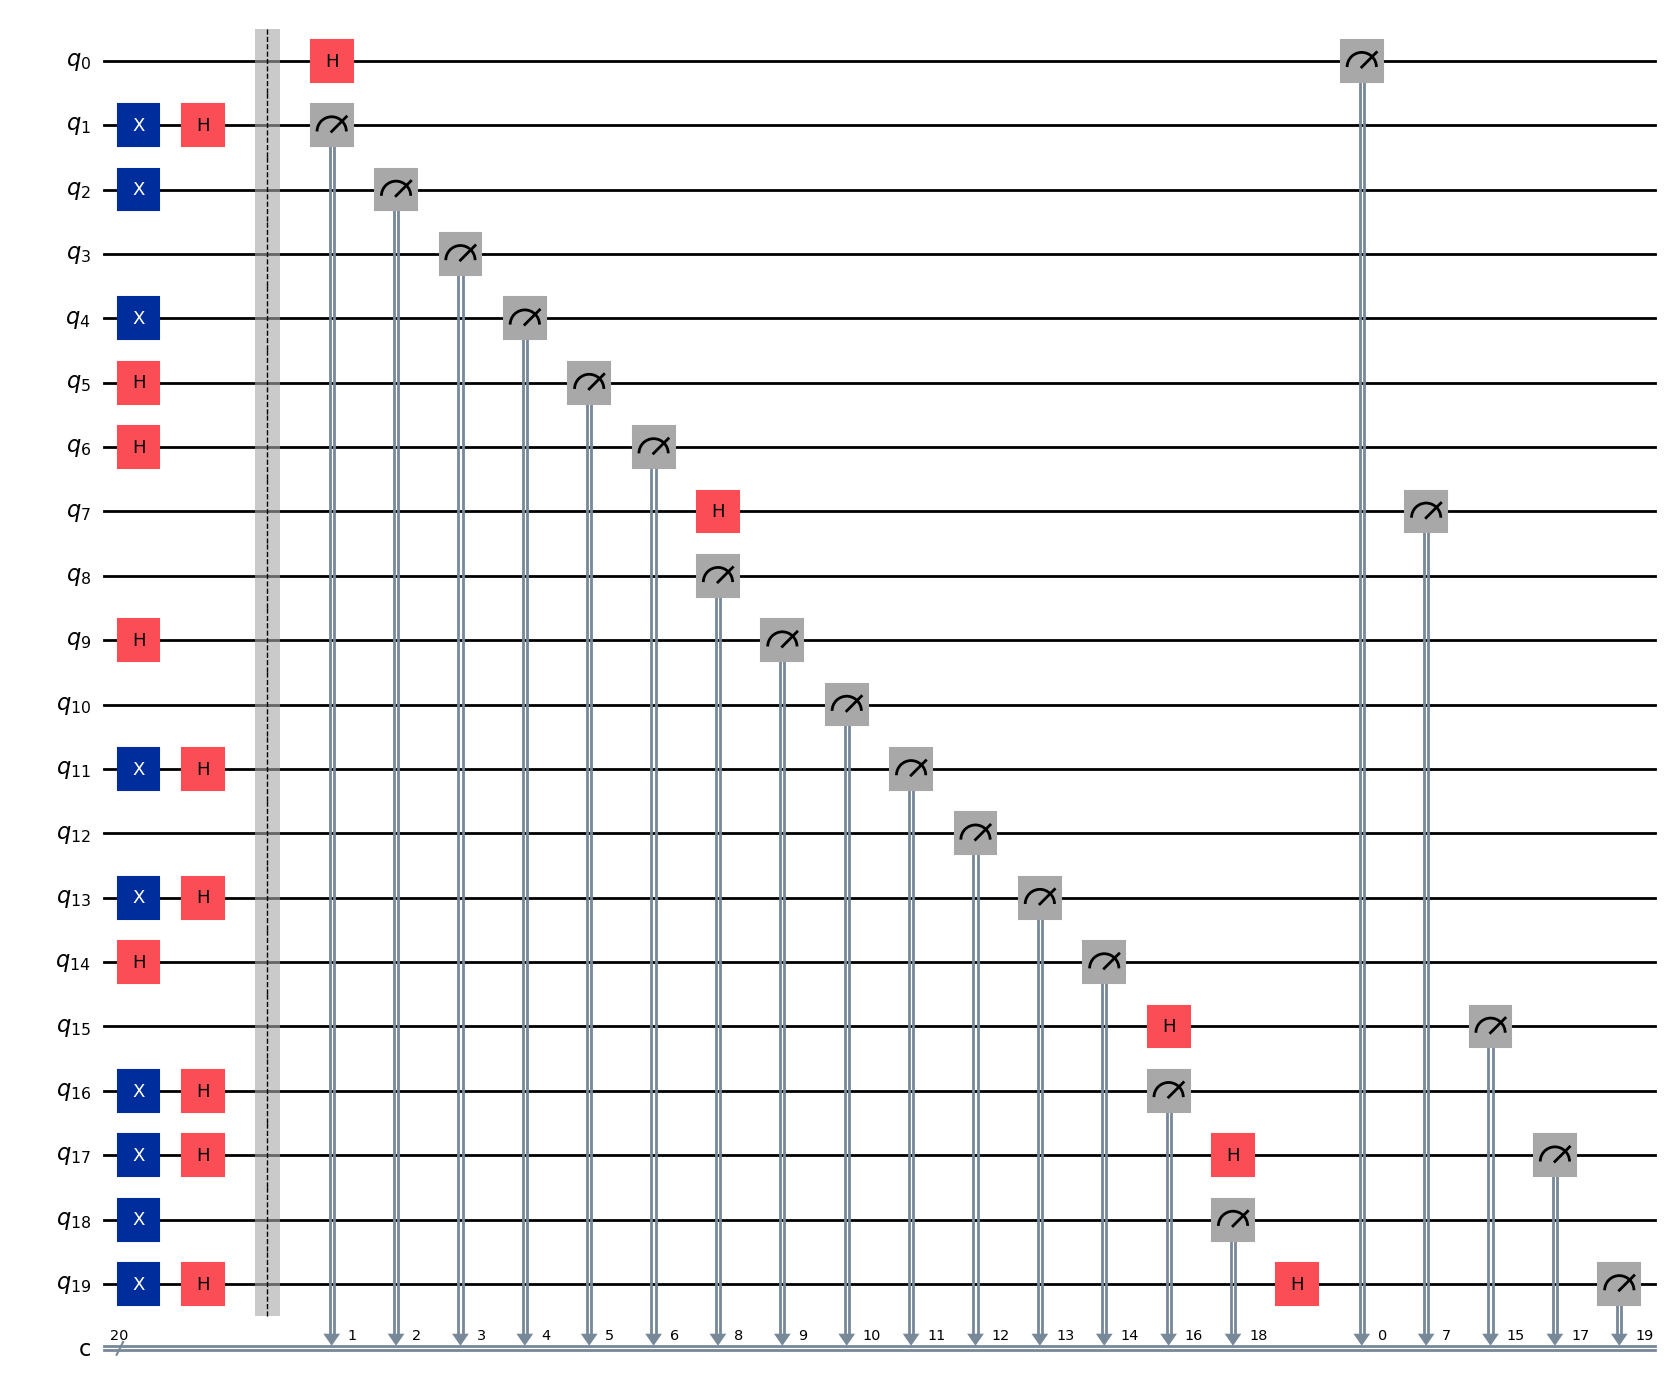

Job ID: d7bccr3klj2c73ev36k0
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1]
Bob's bases are    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1]
Bob's measured bits: [1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 0, 1, 0, 0, 1, 1, 1, 1]
match_count = 8
fidelity    = 0.8888888888888888
loss        = 0.11111111111111116
Try  1
Job ID: d7bccse5nvhs73a36120
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1]
Bob's bases are    [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1]
Bob's measured bits: [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 0, 1, 0, 0, 0, 1, 1, 1]
match_count = 9
fidelity  

In [710]:
def bb84_on_ibm_hardware(num_try):
    # Setup
    bit_num = 20
    rng = get_rn_generator(123)
    
    # Alice selects random bits and bases
    abits = sample_bits(bit_num, rng)
    abase = sample_bits(bit_num, rng)
    
    # 20 qubits, 20 classical bits for measurement results
    qc = QuantumCircuit(bit_num, bit_num)
    
    # Encoding: Alice prepares qubits
    encode_bb84_states(qc, abits, abase)
    qc.barrier()
    
    # Bob measures in his chosen bases
    bbase = sample_bits(bit_num, rng)
    measure_bb84(qc, bbase)

    if num_try == 0:
        display(qc.draw("mpl"))
    
    # Transpile for the backend
    pm = generate_preset_pass_manager(
        target=backend.target,
        optimization_level=1
    )
    qc_isa = pm.run(qc)
    
    # Execute on hardware
    sampler = Sampler(mode=backend)
    job = sampler.run([qc_isa], shots=1)
    
    print("Job ID:", job.job_id())
    
    result = job.result()
    
    
    # Post-process
    counts, countsint = extract_counts(result)
    bbits = counts_to_bbits(counts, bit_num)
    
    agoodbits, bgoodbits = sift_key(abits, abase, bbase, bbits)
    stats = key_statistics(agoodbits, bgoodbits)
    
    print_protocol_summary(abits, abase, bbase, bbits, agoodbits, bgoodbits, stats)

    if stats["sifted_length"] > 0:
        fidelities.append(stats["fidelity"])
        losses.append(stats["loss"])


# Entry point
trial_num = 10
fidelities = []
losses = []

for trial in range(trial_num):
    print("Try ", trial)
    bb84_on_ibm_hardware(trial)
    
print("Average fidelity =", sum(fidelities) / len(fidelities))
print("Average loss     =", sum(losses) / len(losses))



## 4. Experiment 3: BB84 QKD with Eavesdropper on IBM Hardware (Intercept-Resend, Eve + Noise)
First attack model:
- Eve random basis and measure qubit
- Eve resend it to Bob
- QBER raises ~25% theoretical

In [712]:
def eavesdropper_experiment():
    # Setup
    bit_num = 20
    rng = get_rn_generator(123)
    # Alice selects random bits and bases
    abits = sample_bits(bit_num, rng)
    abase = sample_bits(bit_num, rng)
    
    # Part 1: Alice -> Eve
    qc_eve = QuantumCircuit(bit_num, bit_num)
    
    # Alice prepares qubits
    encode_bb84_states(qc_eve, abits, abase)
    qc_eve.barrier()
    
    # Eve measures in her chosen bases
    ebase = sample_bits(bit_num, rng)
    measure_bb84(qc_eve, ebase)
    # display(qc_eve.draw("mpl"))

    # # NOTE: Local simulate
    # sampler_simulate = StatevectorSampler()
    # result_eve = sampler_simulate.run([qc_eve], shots=1).result()
    # counts_eve, _ = extract_counts(result_eve)
    # ebits = counts_to_bbits(counts_eve, bit_num)

    # On hardware
    # Transpile for the backend
    pm = generate_preset_pass_manager(
        target=backend.target,
        optimization_level=1
    )
    qc_eve_isa = pm.run(qc_eve)
    
    # Execute Eve's interception on hardware
    sampler = Sampler(mode=backend)
    job_eve = sampler.run([qc_eve_isa], shots=1)
    print("Eve Job ID:", job_eve.job_id())
    result_eve = job_eve.result()
    counts_eve, countsint_eve = extract_counts(result_eve)
    # Post-processing
    ebits = counts_to_bbits(counts_eve, bit_num)
    print("Eve's bits:\n", ebits)
    
    
    # Part 2: Eve -> Bob
    # Eve construct guess states to send on to Bob
    qc_bob = QuantumCircuit(bit_num, bit_num)
    # Eve encodes using her measured bits in her chosen bases
    encode_bb84_states(qc_bob, ebits, ebase)
    qc_bob.barrier()
    
    # Bob measures in his chosen bases
    bbase = sample_bits(bit_num, rng)
    measure_bb84(qc_bob, bbase)
    # display(qc_bob.draw("mpl"))
    
    # # Local simulate
    # result_bob = sampler_simulate.run([qc_bob], shots=1).result()
    # counts_bob, _ = extract_counts(result_bob)
    # bbits = counts_to_bbits(counts_bob, bit_num)    
    
    # Transpile for the backend
    qc_bob_isa = pm.run(qc_bob)
    # Execute Bob's measurement on hardware
    job_bob = sampler.run([qc_bob_isa], shots=1)
    print("Bob Job ID:", job_bob.job_id())
    result_bob = job_bob.result()
    # Post-process Bob's measurement
    counts_bob, countsint_bob = extract_counts(result_bob)
    bbits = counts_to_bbits(counts_bob, bit_num)
    
    # Compare Alice's and Bob's bits
    agoodbits, bgoodbits = sift_key(abits, abase, bbase, bbits)
    stats = key_statistics(agoodbits, bgoodbits)
    print_protocol_summary(abits, abase, bbase, bbits, agoodbits, bgoodbits, stats, ebits, ebase)
    
    if stats["sifted_length"] > 0:
        fidelities.append(stats["fidelity"])
        losses.append(stats["loss"])

# Entry point
trial_num = 5
fidelities = []
losses = []

for trial in range(trial_num):
    print("Try ", trial)
    eavesdropper_experiment()
    
print("Average fidelity =", sum(fidelities) / len(fidelities))
print("Average loss     =", sum(losses) / len(losses))

    

Try  0
Eve Job ID: d7bcdg30g7hs73dpdd90
Eve's bits:
 [1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1]
Bob Job ID: d7bcdhb0g7hs73dpddbg
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  [0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1]
Eve base:    [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1]
Eve bits:    [1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1]
Bob's bases are    [1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1]
Bob's measured bits: [1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1]
Alice sifted key: [1, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 0, 0, 0, 0, 1, 1, 1]
match_count = 7
fidelity    = 0.875
loss        = 0.125
Try  1
Eve Job ID: d7bcdj3klj2c73ev37hg
Eve's bits:
 [1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1]
Bob Job ID: d7bcdkr0g7hs73dpddf0
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  [0, 1, 0, 0, 0, 

## 5. Experiment 4: Error correction
- Classical post-processing
- parity check
- Show QBER decreases after correction

## 6. Experiment 5: Privacy Amplification
- Hashing SHA
- Compress key
- Final key could be shorter but secure b/c Eve information decreases 

## References:
https://quantum.cloud.ibm.com/learning/en/modules/computer-science/quantum-key-distribution